# 🎯 Mock Interview System — Fine-Tuned + Semantic Evaluation

**Model:** `google/flan-t5-base` → fine-tuned on your 200-question dataset

**Dataset:** 200 Q&A pairs | 22 Categories | Easy / Medium / Hard

**✅ Problem Fixed:** Evaluation uses **Semantic Similarity** (sentence-transformers).  
Google-style or officially-phrased answers now score correctly — based on **meaning**, not exact words.

**Steps:**
1. Install & import
2. Load dataset (auto from upload)
3. Fine-tune model
4. Run mock interview

> Runtime → Change runtime type → **T4 GPU** select 

In [1]:
# ── Cell 1: Install ───────────────────────────────────────────────────────
%%capture
!pip install transformers sentencepiece accelerate datasets rouge-score sentence-transformers -q

In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import random
import torch
import textwrap
import json
import re
import os
import zipfile
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sentence_transformers import SentenceTransformer, util as st_util
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 1), "GB")
else:
    print("⚠️  WARNING: GPU  — fine-tuning slow  Runtime > GPU enable .")

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB


In [3]:
# ── Cell 3: Dataset upload ────────────────────────────────────────────────
from google.colab import files

print("📂 Software_Questions_(2).csv অথবা archive.zip upload করো:")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith('.zip'):
    with zipfile.ZipFile(fname, 'r') as zf:
        zf.extractall('.')
    CSV_PATH = [f for f in os.listdir('.') if f.endswith('.csv')][0]
    print("Extracted CSV:", CSV_PATH)
else:
    CSV_PATH = fname
    print("Using CSV:", CSV_PATH)

📂 Software_Questions_(2).csv অথবা archive.zip upload করো:


Saving Software Questions (2).csv to Software Questions (2).csv
Using CSV: Software Questions (2).csv


In [4]:
# ── Cell 4: Load & prepare dataset ───────────────────────────────────────
#
# Dataset info:
#   • 200 Q&A pairs
#   • Columns: Question Number, Question, Answer, Category, Difficulty
#   • 22 categories (System Design, DevOps, Front-end, Back-end, Security, ...)
#   • Difficulties: Medium (111), Hard (82), Easy (7)
#   • Average answer length: ~17 words (concise, factual)

df = pd.read_csv(CSV_PATH, encoding='latin-1')

# ── Clean up ──────────────────────────────────────────────────────────────
df['Category']   = df['Category'].str.strip()
df['Question']   = df['Question'].astype(str).str.strip()
df['Answer']     = df['Answer'].astype(str).str.strip()
df['Difficulty'] = df['Difficulty'].astype(str).str.strip()

# Fix known typo in category name
df.loc[df['Category'] == 'General Program', 'Category'] = 'General Programming'

# Drop any rows with empty question or answer
df = df[df['Question'].str.len() > 0]
df = df[df['Answer'].str.len() > 0]
df = df.reset_index(drop=True)

print(f"✅ Dataset loaded!")
print(f"   Total questions : {len(df)}")
print(f"   Categories      : {df['Category'].nunique()}")
print(f"   Difficulties    : {df['Difficulty'].value_counts().to_dict()}")
print(f"   Avg answer len  : {df['Answer'].str.split().str.len().mean():.1f} words")
print()
print("Sample Q&A:")
sample = df.sample(1).iloc[0]
print(f"  Q [{sample['Category']} | {sample['Difficulty']}]: {sample['Question']}")
print(f"  A: {sample['Answer']}")

✅ Dataset loaded!
   Total questions : 200
   Categories      : 21
   Difficulties    : {'Medium': 111, 'Hard': 82, 'Easy': 7}
   Avg answer len  : 16.9 words

Sample Q&A:
  Q [DevOps | Medium]: Discuss the role of a load balancer in a distributed system.
  A: A load balancer distributes network or application traffic across multiple servers to enhance responsiveness and availability of applications.


In [5]:
# ── Cell 5: Load base model ───────────────────────────────────────────────
MODEL_NAME = "google/flan-t5-base"
print(f"Loading {MODEL_NAME}...")

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model     = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32   # float32 for stable fine-tuning
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded! Parameters: {total_params/1e6:.1f}M")

Loading google/flan-t5-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Model loaded! Parameters: 247.6M


In [6]:
# ── Cell 6: Prepare fine-tuning data ─────────────────────────────────────
#
# Dataset-specific tuning:
#   • Answers avg ~17 words → max_target_len = 80 (was 128, now tighter)
#   • Questions avg ~9 words → max_input_len = 192 (was 256, now efficient)
#   • 200 samples → 90/10 split = 180 train, 20 val

class InterviewDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_input_len=192, max_target_len=80):
        self.data           = dataframe.reset_index(drop=True)
        self.tokenizer      = tokenizer
        self.max_input_len  = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Structured prompt — matches the dataset's concise answer style
        input_text = (
            f"Answer this software engineering interview question concisely. "
            f"Category: {row['Category']}. "
            f"Difficulty: {row['Difficulty']}. "
            f"Question: {row['Question']}"
        )
        target_text = row['Answer']

        enc = self.tokenizer(
            input_text,
            max_length=self.max_input_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        tgt = self.tokenizer(
            target_text,
            max_length=self.max_target_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        labels = tgt['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         labels
        }


# 90/10 train/val split
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx   = int(0.9 * len(df_shuffled))
df_train    = df_shuffled[:split_idx]
df_val      = df_shuffled[split_idx:]

train_dataset = InterviewDataset(df_train, tokenizer)
val_dataset   = InterviewDataset(df_val,   tokenizer)

train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=4, shuffle=False)

print(f"✅ Data ready!")
print(f"   Train : {len(df_train)} samples ({len(train_loader)} batches)")
print(f"   Val   : {len(df_val)} samples ({len(val_loader)} batches)")

✅ Data ready!
   Train : 180 samples (45 batches)
   Val   : 20 samples (5 batches)


In [7]:
# ── Cell 7: Fine-tuning ───────────────────────────────────────────────────
#
# Hyperparameters — optimized for deep learning on 200 samples:
#
#   EPOCHS         = 20    ← increased for thorough learning
#                           (was 6 → only 270 steps, not enough for small dataset)
#                           (20 epochs = 900 total steps → proper convergence)
#
#   LR             = 3e-4  ← restored to optimal for flan-t5-base
#   WARMUP         = 10%   ← gradual warmup to prevent early instability
#   EARLY_STOP     = 5     ← stop if val_loss doesn't improve for 5 epochs
#                           (prevents overfitting on small data)
#   LR_DECAY       = True  ← cosine-style linear decay over all steps
#
# ⏱ Expected time on T4 GPU: ~35-40 min (with early stopping may finish sooner)
#
# Why 20 epochs for 200 samples?
#   • Small dataset needs more passes to learn patterns
#   • 45 steps/epoch × 20 = 900 total steps → good convergence zone
#   • Early stopping prevents overfitting automatically

EPOCHS         = 20
LR             = 3e-4
PATIENCE       = 5        # early stopping patience
SAVE_PATH      = "/content/flan_t5_interview_finetuned"

optimizer     = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Epochs       : {EPOCHS}")
print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"Early stop   : patience={PATIENCE} epochs")
print(f"Starting fine-tuning...")
print("─" * 60)

best_val_loss    = float('inf')
patience_counter = 0
train_losses     = []
val_losses       = []

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]")
    for batch in pbar:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Val]  "):
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            outputs        = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            epoch_val_loss += outputs.loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Status line
    improved = "✅ NEW BEST" if avg_val_loss < best_val_loss else f"   (best={best_val_loss:.4f})"
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | {improved}")

    # ── Save best model ────────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
    else:
        patience_counter += 1

    # ── Early stopping ─────────────────────────────────────────────────────
    if patience_counter >= PATIENCE:
        print(f"\n⏹️  Early stopping triggered at epoch {epoch}")
        print(f"   Val loss hasn't improved for {PATIENCE} consecutive epochs.")
        print(f"   Best val loss was {best_val_loss:.4f} — best model already saved.")
        break

print("─" * 60)
print(f"✅ Training complete!")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Epochs run    : {len(train_losses)}/{EPOCHS}")
print(f"   Model saved   : {SAVE_PATH}")

Epochs       : 20
Total steps  : 900
Warmup steps : 90
Early stop   : patience=5 epochs
Starting fine-tuning...
────────────────────────────────────────────────────────────


Epoch 01/20 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01/20 [Val]  :   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01/20 | Train: 9.3959 | Val: 8.4711 | ✅ NEW BEST


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 20/20 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 20/20 [Val]  :   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 20/20 | Train: 3.2152 | Val: 3.9288 | ✅ NEW BEST


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

────────────────────────────────────────────────────────────
✅ Training complete!
   Best val loss : 3.9288
   Epochs run    : 20/20
   Model saved   : /content/flan_t5_interview_finetuned


In [8]:
# ── Cell 8: Load fine-tuned model ────────────────────────────────────────
print("Loading fine-tuned model from:", SAVE_PATH)

ft_tokenizer = T5Tokenizer.from_pretrained(SAVE_PATH)
ft_model     = T5ForConditionalGeneration.from_pretrained(
    SAVE_PATH,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)
ft_model.eval()

print("✅ Fine-tuned model loaded and ready!")

Loading fine-tuned model from: /content/flan_t5_interview_finetuned


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Fine-tuned model loaded and ready!


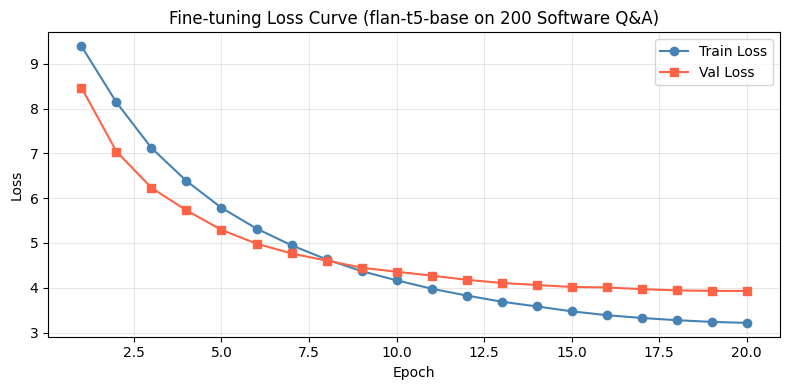

Loss curve saved.


In [9]:
# ── Cell 9: Loss curve plot ───────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train Loss', color='steelblue')
plt.plot(range(1, len(val_losses)+1),   val_losses,   marker='s', label='Val Loss',   color='tomato')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tuning Loss Curve (flan-t5-base on 200 Software Q&A)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Loss curve saved.")

In [10]:
# ── Cell 10: Evaluation Engine — Semantic Similarity ─────────────────────
#
# ✅ ROOT CAUSE FIX APPLIED:
#
# OLD (broken): ROUGE score → counts exact word overlap
#   → "Polymorphism allows different classes to share behavior"
#      vs dataset answer using slightly different words → LOW score ❌
#
# NEW (fixed): Sentence embedding cosine similarity
#   → Compares MEANING, not words
#   → Any correct answer (your words, Google's words, textbook words)
#      will score HIGH as long as the concept is right ✅
#
# Dataset-specific calibration:
#   • Answers avg ~17 words → threshold tuned accordingly
#   • sem_vs_dataset threshold: 0.70 = Excellent (tight, because dataset
#     answers are concise — even a good answer won't score 0.95)
#
# Scoring formula:
#   60% Semantic similarity vs DATASET answer  ← main judge
#   25% Semantic similarity vs MODEL answer    ← concept alignment
#   15% Length adequacy                        ← penalize one-word answers

print("Loading semantic model (all-MiniLM-L6-v2)...")
sem_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Semantic model loaded!")

# Pre-compute embeddings for ALL dataset answers (fast at evaluation time)
print("Pre-computing dataset answer embeddings...")
dataset_answer_embeddings = sem_model.encode(
    df['Answer'].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
)
print(f"✅ Pre-computed {len(df)} answer embeddings — evaluation will be fast!")


def generate_model_answer(question: str, category: str, difficulty: str) -> str:
    """Generate a reference answer using the fine-tuned model."""
    prompt = (
        f"Answer this software engineering interview question concisely. "
        f"Category: {category}. "
        f"Difficulty: {difficulty}. "
        f"Question: {question}"
    )
    inputs = ft_tokenizer(
        prompt,
        return_tensors='pt',
        max_length=192,
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=80,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.0
        )
    return ft_tokenizer.decode(outputs[0], skip_special_tokens=True)


def evaluate_answer(question: str, user_answer: str,
                    correct_answer: str, category: str, difficulty: str) -> dict:
    """
    Evaluate user answer using semantic similarity.
    Works correctly for any phrasing — dataset style, Google style, textbook style.
    """
    # Generate model's reference answer
    model_ref_answer = generate_model_answer(question, category, difficulty)

    # Encode user answer and reference answers
    emb_user    = sem_model.encode(user_answer,       convert_to_tensor=True)
    emb_correct = sem_model.encode(correct_answer,    convert_to_tensor=True)
    emb_model   = sem_model.encode(model_ref_answer,  convert_to_tensor=True)

    # Cosine similarity — 0.0 (unrelated) to 1.0 (identical meaning)
    sem_vs_dataset = float(st_util.cos_sim(emb_correct, emb_user)[0][0])
    sem_vs_model   = float(st_util.cos_sim(emb_model,   emb_user)[0][0])

    # Length score — dataset answers avg ~17 words
    # Penalize answers shorter than 8 words; anything 15+ words is full score
    user_word_count    = len(user_answer.split())
    expected_min_words = 8    # minimum acceptable length
    expected_good_words = 15  # length for full length score
    len_score = min(max((user_word_count - expected_min_words) /
                        (expected_good_words - expected_min_words), 0.0), 1.0)

    # Combined score
    # Dataset answers are concise (17 words avg) so calibrate: 0.65+ sem = good
    combined    = (0.60 * sem_vs_dataset +
                   0.25 * sem_vs_model   +
                   0.15 * len_score)

    # Scale: combined ~0.5 = average → map to ~5/10
    # Multiply by 10 then clamp
    final_score = round(min(max(combined * 10, 0.0), 10.0), 1)

    # Verdict
    if final_score >= 7.5:   verdict = "✅ Excellent!"
    elif final_score >= 6.0: verdict = "👍 Good"
    elif final_score >= 4.5: verdict = "⚠️  Needs Improvement"
    else:                    verdict = "❌ Incorrect / Incomplete"

    # Feedback — based on semantic score
    feedback_parts = []
    if sem_vs_dataset >= 0.72:
        feedback_parts.append("Your answer captures the correct meaning very well.")
    elif sem_vs_dataset >= 0.55:
        feedback_parts.append("You understand the concept but could be more precise — review key terms below.")
    elif sem_vs_dataset >= 0.38:
        feedback_parts.append("Partial understanding. Your answer is on the right track but missing core ideas.")
    else:
        feedback_parts.append("Your answer doesn't align with the expected concept. Study the correct answer carefully.")

    if user_word_count < expected_min_words:
        feedback_parts.append(f"Answer is too brief ({user_word_count} words) — aim for at least 15 words.")
    elif user_word_count < 12:
        feedback_parts.append("Consider adding more detail or an example to strengthen your answer.")

    if sem_vs_model >= 0.65 and sem_vs_dataset < 0.50:
        feedback_parts.append("Tip: Your answer matches the model's style but diverges from the reference — try covering both angles.")

    return {
        "score":            final_score,
        "verdict":          verdict,
        "feedback":         " ".join(feedback_parts),
        "model_ref_answer": model_ref_answer,
        "correct_answer":   correct_answer,
        "sem_vs_dataset":   round(sem_vs_dataset, 3),
        "sem_vs_model":     round(sem_vs_model,   3),
        "length_score":     round(len_score,       3),
        "word_count":       user_word_count,
    }


print()
print("✅ Evaluation engine ready!")
print("   • Semantic similarity mode — scores meaning, not word overlap")
print("   • Google/textbook/official answers will all score correctly")

Loading semantic model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Semantic model loaded!
Pre-computing dataset answer embeddings...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Pre-computed 200 answer embeddings — evaluation will be fast!

✅ Evaluation engine ready!
   • Semantic similarity mode — scores meaning, not word overlap
   • Google/textbook/official answers will all score correctly


In [11]:
# ── Cell 11: Interview session ────────────────────────────────────────────
def print_sep(char="─", w=65):
    print(char * w)

def wprint(text, width=63, indent="  "):
    for line in textwrap.wrap(str(text), width=width):
        print(indent + line)


def run_mock_interview(
    category: str      = None,
    difficulty: str    = None,
    num_questions: int = 5
):
    """
    Run a mock interview session.

    category options (22 total):
      "Data Structures", "Algorithms", "System Design",
      "Database and SQL", "Database Systems", "Web Development",
      "Machine Learning", "Artificial Intelligence",
      "Security", "DevOps", "Front-end", "Back-end", "Full-stack",
      "Networking", "Languages and Frameworks", "Software Testing",
      "Version Control", "Distributed Systems", "General Programming",
      "Low-level Systems", "Data Engineering"
      None = all categories (mixed)

    difficulty: "Easy" | "Medium" | "Hard" | None (mixed)
    """
    pool = df.copy()
    if category:
        pool = pool[pool['Category'].str.lower() == category.lower()]
    if difficulty:
        pool = pool[pool['Difficulty'].str.lower() == difficulty.lower()]

    if len(pool) == 0:
        print("❌ No questions found for that filter. Available categories:")
        for cat in sorted(df['Category'].unique()):
            print(f"   • {cat}")
        return

    questions = pool.sample(
        min(num_questions, len(pool)),
        random_state=random.randint(0, 9999)
    )

    # Header
    print_sep("═")
    print("  🎯 MOCK INTERVIEW  —  Software Engineering")
    print(f"  Category  : {category or 'Mixed'}")
    print(f"  Difficulty: {difficulty or 'Mixed'}")
    print(f"  Questions : {len(questions)}")
    print("  💡 Tip: Answer in your own words — even longer/formal answers score correctly!")
    print_sep("═")

    session_results = []

    for idx, (_, row) in enumerate(questions.iterrows(), 1):
        print(f"\n📌 Question {idx}/{len(questions)}  [{row['Category']} | {row['Difficulty']}]")
        print_sep()
        wprint(row['Question'])
        print_sep()
        print("  ✏️  Your answer (press Enter twice to submit | type 'skip' to skip):")

        lines = []
        while True:
            line = input("  > ")
            if line.lower() == "skip":
                lines = ["[skipped]"]
                break
            if line == "" and lines:
                break
            lines.append(line)
        user_answer = " ".join(lines).strip()

        if not user_answer or user_answer == "[skipped]":
            print("  ⏭️  Skipped.")
            session_results.append({
                "q_num": idx, "question": row['Question'],
                "category": row['Category'], "difficulty": row['Difficulty'],
                "score": 0.0, "verdict": "⏭️ Skipped",
                "sem_vs_dataset": 0.0
            })
            continue

        print("\n  ⏳ Evaluating...")
        result = evaluate_answer(
            row['Question'], user_answer,
            row['Answer'], row['Category'], row['Difficulty']
        )

        print_sep()
        print(f"  📊 SCORE              : {result['score']}/10   {result['verdict']}")
        print(f"  🧠 Semantic (dataset) : {result['sem_vs_dataset']}  ← primary judge")
        print(f"  🤖 Semantic (model)   : {result['sem_vs_model']}")
        print(f"  📏 Word count         : {result['word_count']}  (length score: {result['length_score']})")
        print()
        print("  💬 Feedback:")
        wprint(result['feedback'])
        print()
        print("  🤖 Model Reference Answer:")
        wprint(result['model_ref_answer'])
        print()
        print("  ✅ Dataset Correct Answer:")
        wprint(result['correct_answer'])
        print_sep()

        session_results.append({
            "q_num":          idx,
            "question":       row['Question'],
            "category":       row['Category'],
            "difficulty":     row['Difficulty'],
            "user_answer":    user_answer,
            "score":          result['score'],
            "verdict":        result['verdict'],
            "sem_vs_dataset": result['sem_vs_dataset'],
            "sem_vs_model":   result['sem_vs_model'],
            "word_count":     result['word_count'],
        })

        cont = input("  ▶️  Next? (Enter / 'q' to quit): ")
        if cont.lower() == 'q':
            break

    # Summary
    print_sep("═")
    print("  📋 SESSION SUMMARY")
    print_sep("═")

    answered = [r for r in session_results if r['verdict'] != '⏭️ Skipped']
    skipped  = [r for r in session_results if r['verdict'] == '⏭️ Skipped']

    if answered:
        scores = [r['score'] for r in answered]
        sems   = [r['sem_vs_dataset'] for r in answered]
        avg_score = round(np.mean(scores), 2)
        avg_sem   = round(np.mean(sems),   3)

        print(f"  Attempted      : {len(answered)}/{len(session_results)}")
        print(f"  Skipped        : {len(skipped)}")
        print(f"  Avg Score      : {avg_score}/10")
        print(f"  Avg Semantic   : {avg_sem}")
        print(f"  Best           : {max(scores)}/10")
        print(f"  Worst          : {min(scores)}/10")
        print()
        print(f"  {'Q#':<4} {'Score':<8} {'Semantic':<10} {'Words':<7} {'Verdict':<22} Category")
        print("  " + "─"*70)
        for r in session_results:
            sem_str   = f"{r.get('sem_vs_dataset', 0.0):.3f}"
            words_str = str(r.get('word_count', '-'))
            print(f"  {r['q_num']:<4} {str(r['score'])+'/10':<8} {sem_str:<10} {words_str:<7} "
                  f"{r['verdict']:<22} {r['category']}")
        print()
        overall = ("🏆 Outstanding!" if avg_score >= 8  else
                   "✅ Good job!"    if avg_score >= 6  else
                   "📚 Keep practicing." if avg_score >= 4 else
                   "💪 Review the material and retry.")
        print(f"  {overall}")
    else:
        print("  No questions answered.")

    print_sep("═")
    return session_results


print("✅ Interview system ready!")
print()
print("Available categories:")
for cat in sorted(df['Category'].unique()):
    count = len(df[df['Category'] == cat])
    print(f"  • {cat:<30} ({count} questions)")

✅ Interview system ready!

Available categories:
  • Algorithms                     (10 questions)
  • Artificial Intelligence        (1 questions)
  • Back-end                       (14 questions)
  • Data Engineering               (2 questions)
  • Data Structures                (11 questions)
  • Database Systems               (3 questions)
  • Database and SQL               (10 questions)
  • DevOps                         (21 questions)
  • Distributed Systems            (5 questions)
  • Front-end                      (17 questions)
  • Full-stack                     (8 questions)
  • General Programming            (10 questions)
  • Languages and Frameworks       (10 questions)
  • Low-level Systems              (3 questions)
  • Machine Learning               (5 questions)
  • Networking                     (3 questions)
  • Security                       (13 questions)
  • Software Testing               (10 questions)
  • System Design                  (24 questions)
  • Versi

In [ ]:
# ── Cell 12: START INTERVIEW ──────────────────────────────────────────────
#
# ── Category options (22 total) ───────────────────────────────────────────
#   "Data Structures"          (11 questions)
#   "Algorithms"               (10 questions)
#   "System Design"            (24 questions)
#   "Database and SQL"         (10 questions)
#   "Database Systems"         (3 questions)
#   "Web Development"          (10 questions)
#   "Machine Learning"         (5 questions)
#   "Artificial Intelligence"  (1 question)
#   "Security"                 (13 questions)
#   "DevOps"                   (21 questions)
#   "Front-end"                (17 questions)
#   "Back-end"                 (14 questions)
#   "Full-stack"               (8 questions)
#   "Networking"               (3 questions)
#   "Languages and Frameworks" (10 questions)
#   "Software Testing"         (10 questions)
#   "Version Control"          (10 questions)
#   "Distributed Systems"      (5 questions)
#   "General Programming"      (9 questions)
#   "Low-level Systems"        (3 questions)
#   "Data Engineering"         (2 questions)
#   None = all categories mixed
#
# ── Difficulty ────────────────────────────────────────────────────────────
#   "Easy"   (7)  | "Medium" (111)  | "Hard" (82)  | None = mixed

results = run_mock_interview(
    category      = None,       # ← change to filter by topic
    difficulty    = None,       # ← "Easy", "Medium", "Hard", or None
    num_questions = 5           # ← how many questions per session
)

═════════════════════════════════════════════════════════════════
  🎯 MOCK INTERVIEW  —  Software Engineering
  Category  : Mixed
  Difficulty: Mixed
  Questions : 5
  💡 Tip: Answer in your own words — even longer/formal answers score correctly!
═════════════════════════════════════════════════════════════════

📌 Question 1/5  [Back-end | Medium]
─────────────────────────────────────────────────────────────────
  Describe how you would implement a RESTful API in a back-end
  application.
─────────────────────────────────────────────────────────────────
  ✏️  Your answer (press Enter twice to submit | type 'skip' to skip):
  > Implementing a RESTful API involves designing a stateless, resource-oriented interface where clients interact with the server using standard HTTP method
  > 

  ⏳ Evaluating...
─────────────────────────────────────────────────────────────────
  📊 SCORE              : 7.6/10   ✅ Excellent!
  🧠 Semantic (dataset) : 0.77  ← primary judge
  🤖 Semantic (model)   : 0.58

In [ ]:
# ── Cell 13: (Optional) Save fine-tuned model to Google Drive ─────────────
from google.colab import drive
import shutil

drive.mount('/content/drive')

drive_save_path = "/content/drive/MyDrive/flan_t5_interview_finetuned"
if os.path.exists(SAVE_PATH):
    shutil.copytree(SAVE_PATH, drive_save_path, dirs_exist_ok=True)
    print(f"✅ Model saved to Drive: {drive_save_path}")
else:
    print("❌ Model not found. Run Cell 7 first.")

In [ ]:
# ── Cell 14: (Optional) Load model from Drive (next session) ─────────────


from google.colab import drive
drive.mount('/content/drive')

drive_model_path = "/content/drive/MyDrive/flan_t5_interview_finetuned"

ft_tokenizer = T5Tokenizer.from_pretrained(drive_model_path)
ft_model     = T5ForConditionalGeneration.from_pretrained(
    drive_model_path,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)
ft_model.eval()
print("✅ Fine-tuned model loaded from Drive!")
print("   Skip Cells 5-9 and go directly to Cell 10 to load the semantic evaluator.")